In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report

In [2]:
data = pd.read_csv('Model 2.csv', encoding='latin-1')

In [3]:
data

,Risk Level,Trimester,Fitness Level,Pregnancy Complications,Specific Goal,Activity Before Pregnancy,Recommended Exercises,Category Number
0,Low,1,Beginner,NaN,NaN,Sedentary,"Walking, Swimming",1
1,High,2,Intermediate,"Back Pain, Pelvic Floor Weakness","Back Pain Relief, Preparation for Labor",Moderately Active,"Modified Cat Cow, Kegels",19
2,Low,3,Advanced,NaN,Preparation for Labor,Very Active,"Deep Squats, Perineal Massage",17
3,Low,1,Beginner,Gestational Diabetes,Weight Control,Sedentary,"Walking, Pelvic Floor Awareness",20
4,High,2,Intermediate,Diastasis Recti,Preparation for Labor,Moderately Active,"Pelvic Floor Awareness, Supported Pigeon Pose",6
...,...,...,...,...,...,...,...,...
1929,High,3,Advanced,"Pelvic Floor Weakness, Back Pain",Preparation for Labor,Very Active,"Deep Squats, Perineal Massage",17
1930,Low,1,Intermediate,Gestational Diabetes,Weight Control,Moderately Active,"Swimming, Light Weight Training",22
1931,Low,2,Beginner,Diastasis Recti,Weight Control,Sedentary,"Stationary Cycling, Seated Forward Bend",5
1932,High,1,Advanced,NaN,General Fitness,Very Active,"Dancing, Light Weight Training",18


<Axes: >

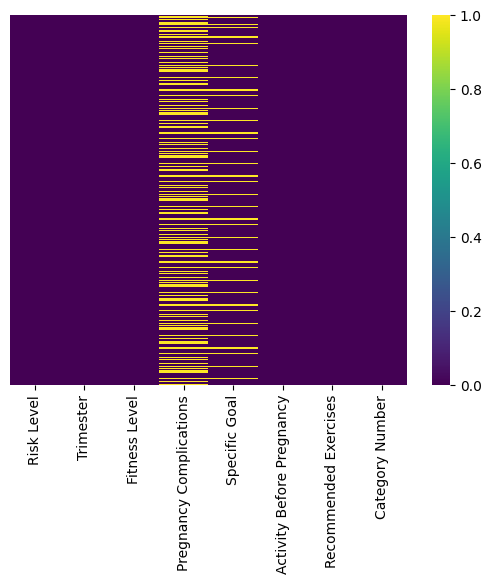

In [4]:
sns.heatmap(data.isnull(),yticklabels=False, cmap="viridis")

In [5]:
data["Pregnancy Complications"].fillna("None", inplace=True)

C:\Users\Kale\AppData\Local\Temp\ipykernel_14708\4168442613.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Pregnancy Complications"].fillna("None", inplace=True)


In [6]:
data["Specific Goal"].fillna("None", inplace=True)

C:\Users\Kale\AppData\Local\Temp\ipykernel_14708\2526744147.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Specific Goal"].fillna("None", inplace=True)


<Axes: >

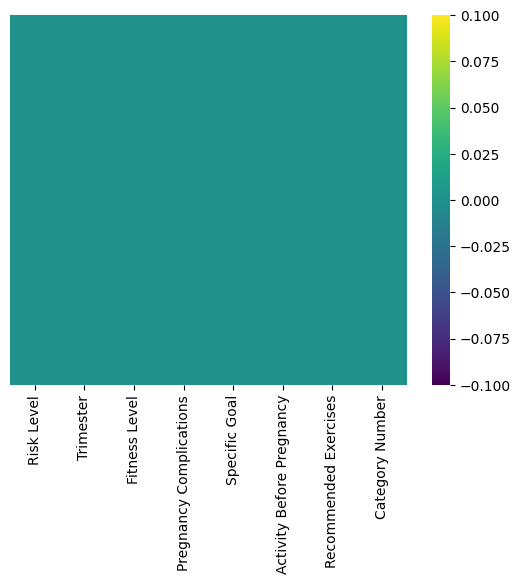

In [7]:
sns.heatmap(data.isnull(),yticklabels=False, cmap="viridis")

In [8]:
data

,Risk Level,Trimester,Fitness Level,Pregnancy Complications,Specific Goal,Activity Before Pregnancy,Recommended Exercises,Category Number
0,Low,1,Beginner,None,None,Sedentary,"Walking, Swimming",1
1,High,2,Intermediate,"Back Pain, Pelvic Floor Weakness","Back Pain Relief, Preparation for Labor",Moderately Active,"Modified Cat Cow, Kegels",19
2,Low,3,Advanced,None,Preparation for Labor,Very Active,"Deep Squats, Perineal Massage",17
3,Low,1,Beginner,Gestational Diabetes,Weight Control,Sedentary,"Walking, Pelvic Floor Awareness",20
4,High,2,Intermediate,Diastasis Recti,Preparation for Labor,Moderately Active,"Pelvic Floor Awareness, Supported Pigeon Pose",6
...,...,...,...,...,...,...,...,...
1929,High,3,Advanced,"Pelvic Floor Weakness, Back Pain",Preparation for Labor,Very Active,"Deep Squats, Perineal Massage",17
1930,Low,1,Intermediate,Gestational Diabetes,Weight Control,Moderately Active,"Swimming, Light Weight Training",22
1931,Low,2,Beginner,Diastasis Recti,Weight Control,Sedentary,"Stationary Cycling, Seated Forward Bend",5
1932,High,1,Advanced,None,General Fitness,Very Active,"Dancing, Light Weight Training",18


In [9]:
data=data.drop(['Recommended Exercises'], axis=1)

In [10]:
label_encoders = {}
for col in ['Risk Level','Fitness Level','Pregnancy Complications','Specific Goal','Activity Before Pregnancy']:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le
    print(f"\n{col} mapping:")
    print(dict(zip(le.classes_, le.transform(le.classes_))))


Risk Level mapping:
{'High': 0, 'Low': 1}

Fitness Level mapping:
{'Advanced': 0, 'Beginner': 1, 'Intermediate': 2}

Pregnancy Complications mapping:
{'Back Pain': 0, 'Back Pain, Diastasis Recti': 1, 'Back Pain, Gestational Diabetes': 2, 'Back Pain, Pelvic Floor Weakness': 3, 'Back Pain, Pelvic Girdle Pain': 4, 'Diastasis Recti': 5, 'Diastasis Recti, Pelvic Floor Weakness': 6, 'Gestational Diabetes': 7, 'None': 8, 'Pelvic Floor Weakness': 9, 'Pelvic Floor Weakness, Back Pain': 10, 'Pelvic Floor Weakness, Diastasis Recti': 11, 'Pelvic Floor Weakness, Gestational Diabetes': 12, 'Pelvic Girdle Pain': 13, 'Pelvic Girdle Pain, Back Pain': 14, 'Pelvic Girdle Pain, Diastasis Recti': 15, 'Pelvic Girdle Pain, Gestational Diabetes': 16, 'Pelvic Girdle Pain, Pelvic Floor Weakness': 17}

Specific Goal mapping:
{'Back Pain Relief': 0, 'Back Pain Relief, Preparation for Labor': 1, 'Back Pain Relief, Weight Control': 2, 'Core Strengthening': 3, 'General Fitness': 4, 'None': 5, 'Pelvic Floor Strength

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1934 entries, 0 to 1933
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Risk Level                 1934 non-null   int32
 1   Trimester                  1934 non-null   int64
 2   Fitness Level              1934 non-null   int32
 3   Pregnancy Complications    1934 non-null   int32
 4   Specific Goal              1934 non-null   int32
 5   Activity Before Pregnancy  1934 non-null   int32
 6   Category Number            1934 non-null   int64
dtypes: int32(5), int64(2)
memory usage: 68.1 KB


In [12]:
data.describe()

,Risk Level,Trimester,Fitness Level,Pregnancy Complications,Specific Goal,Activity Before Pregnancy,Category Number
count,1934.000000,1934.000000,1934.000000,1934.000000,1934.000000,1934.000000,1934.000000
mean,0.666494,2.001034,1.131851,7.485005,5.297828,0.869183,11.741986
std,0.471587,0.815651,0.777789,3.575587,3.198588,0.777963,6.822419
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,1.000000,1.000000,6.000000,3.000000,0.000000,6.000000
50%,1.000000,2.000000,1.000000,8.000000,6.000000,1.000000,11.000000
75%,1.000000,3.000000,2.000000,9.000000,8.000000,1.000000,17.750000
max,1.000000,3.000000,2.000000,17.000000,9.000000,2.000000,25.000000


In [13]:
data.isnull().sum()

Risk Level                   0
Trimester                    0
Fitness Level                0
Pregnancy Complications      0
Specific Goal                0
Activity Before Pregnancy    0
Category Number              0
dtype: int64

In [14]:
X = data[['Risk Level','Trimester','Fitness Level','Pregnancy Complications','Specific Goal','Activity Before Pregnancy']]
y = data[['Category Number']]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [16]:
def model_score(model):
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    print(str(model)+ ' | ' +str(acc))

In [17]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
model_score(lr)

from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
model_score(rf)

from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
model_score(knn)

from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
model_score(logreg)

from sklearn.linear_model import Lasso
lasso = Lasso()
model_score(lasso)

from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
model_score(dt)

LinearRegression() | 0.1624670553275691


C:\Users\Kale\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\Kale\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\Kale\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


RandomForestRegressor() | 0.698182583941492
KNeighborsClassifier(n_neighbors=3) | 0.882960413080895
LogisticRegression() | 0.8502581755593803
Lasso() | 0.14608210316406411
DecisionTreeRegressor() | 0.6909876568013091


C:\Users\Kale\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [18]:
import pickle

pickle.dump(logreg, open("recom_model.dat", "wb"))

In [19]:
predict=np.round(logreg.predict(X_test))

<class 'numpy.ndarray'>
<class 'pandas.core.frame.DataFrame'>


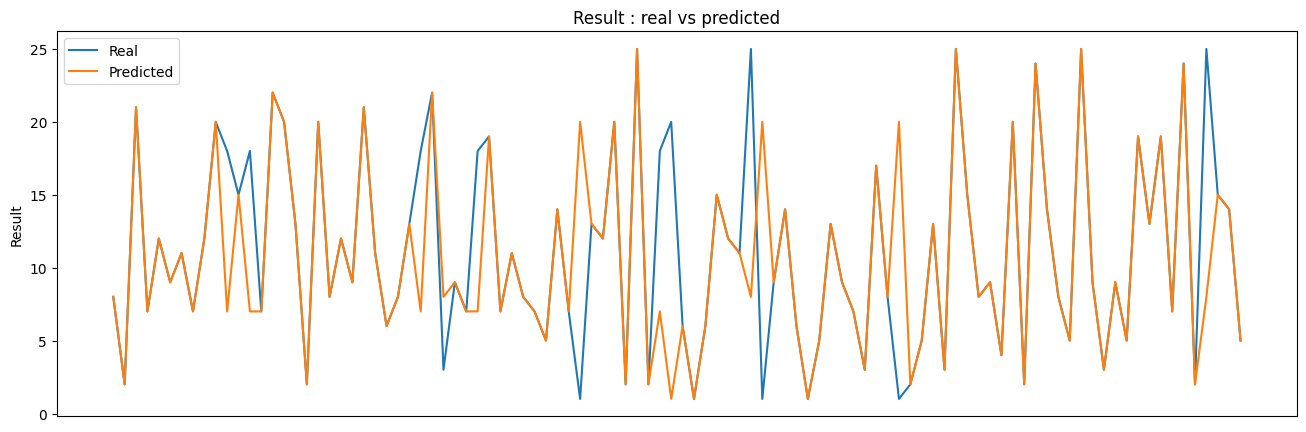

In [20]:
A = np.array(y_test).reshape(-1, 1)
B = predict.reshape(-1, 1)
print(type(predict))
print(type(y_test))
plt.rcParams['figure.figsize'] = 16,5
plt.figure()
plt.plot(A[-100:], label="Real")
plt.plot(B[-100:], label="Predicted")
plt.legend()
plt.title("Result : real vs predicted")
plt.ylabel("Result")
plt.xticks(())
plt.show()

In [21]:
print("Classification Report:")
print(classification_report(y_test, predict))

C:\Users\Kale\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Classification Report:
              precision    recall  f1-score   support

           1       0.79      0.34      0.48        32
           2       0.96      0.96      0.96        28
           3       0.83      0.58      0.68        26
           4       0.83      0.83      0.83        12
           5       1.00      0.97      0.99        37
           6       1.00      1.00      1.00        25
           7       0.62      1.00      0.76        26
           8       0.60      0.94      0.73        35
           9       0.98      1.00      0.99        40
          10       0.00      0.00      0.00         2
          11       1.00      1.00      1.00        36
          12       1.00      0.97      0.98        32
          13       1.00      1.00      1.00        35
          14       0.95      0.62      0.75        32
          15       0.97      0.97      0.97        30
          16       1.00      0.50      0.67         2
          17       0.91      0.91      0.91        11
    

C:\Users\Kale\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Kale\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [22]:
with open('recom_model.dat' , 'rb') as f:
    model = pickle.load(f)

In [23]:
X

,Risk Level,Trimester,Fitness Level,Pregnancy Complications,Specific Goal,Activity Before Pregnancy
0,1,1,1,8,5,1
1,0,2,2,3,1,0
2,1,3,0,8,7,2
3,1,1,1,7,9,1
4,0,2,2,5,7,0
...,...,...,...,...,...,...
1929,0,3,0,10,7,2
1930,1,1,2,7,9,0
1931,1,2,1,5,9,1
1932,0,1,0,8,4,2


In [24]:
model.predict([[1,0,1,8,5,1]])[0]

C:\Users\Kale\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


8